# Noble Addis

This notebook documents the first machine learning workflow for Noble Addis, a property listing review tool for Addis Ababa.

The goal is to use collected listing-level data to support two early review tasks:

1. Estimate a reasonable negotiation reference value.
2. Classify listings into basic review categories such as standard review, needs review, or suspicious.

The dataset used here was collected from public Jiji Ethiopia listing pages for academic MVP testing. Private seller names, phone numbers, and contact details are excluded.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

pd.set_option("display.max_columns", None)

In [4]:
df = pd.read_csv("addis_property_listings.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 20
Columns: 17


,id,title,location,property_type,listed_price_etb,listed_price_usd,size_sqm,bedrooms,bathrooms,amenities_count,completeness_score,description_length,risk_label,image_url,source_platform,listing_url,source_note
0,1,3+ YEARS ON JIJI,Arada,Apartment,180000,3158,100,2,2,2,0.95,214,normal,https://pictures-ethiopia.jijistatic.com/11196...,Jiji Ethiopia,https://jiji.com.et/arada/new-builds/diaspora-...,Public listing data collected from Jiji Ethiop...
1,2,"ETB 169,000 per month 4bdrm Apartment in Kazan...",Kirkos,Apartment,169000,2965,100,4,4,2,0.95,189,normal,https://pictures-ethiopia.jijistatic.com/11700...,Jiji Ethiopia,https://jiji.com.et/kirkos/houses-apartments-f...,Public listing data collected from Jiji Ethiop...
2,3,3+ YEARS ON JIJI,Bole,Property,300000,5263,100,2,2,2,0.90,109,normal,https://pictures-ethiopia.jijistatic.com/10581...,Jiji Ethiopia,https://jiji.com.et/bole/commercial-property-f...,Public listing data collected from Jiji Ethiop...
3,4,3+ YEARS ON JIJI DIAMOND,Bole,Apartment,250000,4386,100,3,3,2,0.95,199,normal,https://pictures-ethiopia.jijistatic.com/97837...,Jiji Ethiopia,https://jiji.com.et/bole/houses-apartments-for...,Public listing data collected from Jiji Ethiop...
4,5,3+ YEARS ON JIJI DIAMOND,Bole,Apartment,90000,1579,100,2,2,2,0.95,206,normal,https://pictures-ethiopia.jijistatic.com/98507...,Jiji Ethiopia,https://jiji.com.et/bole/houses-apartments-for...,Public listing data collected from Jiji Ethiop...


In [5]:
print("Columns in the dataset:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

df.describe(include="all")

Columns in the dataset:
['id', 'title', 'location', 'property_type', 'listed_price_etb', 'listed_price_usd', 'size_sqm', 'bedrooms', 'bathrooms', 'amenities_count', 'completeness_score', 'description_length', 'risk_label', 'image_url', 'source_platform', 'listing_url', 'source_note']

Missing values:
id                    0
title                 0
location              0
property_type         0
listed_price_etb      0
listed_price_usd      0
size_sqm              0
bedrooms              0
bathrooms             0
amenities_count       0
completeness_score    0
description_length    0
risk_label            0
image_url             0
source_platform       0
listing_url           0
source_note           0
dtype: int64


,id,title,location,property_type,listed_price_etb,listed_price_usd,size_sqm,bedrooms,bathrooms,amenities_count,completeness_score,description_length,risk_label,image_url,source_platform,listing_url,source_note
count,20.00000,20,20,20,20.00000,20.000000,20.000000,20.000000,20.000000,20.0,20.000000,20.000000,20,20,20,20,20
unique,NaN,7,6,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,20,1,20,1
top,NaN,3+ YEARS ON JIJI,Bole,Apartment,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,normal,https://pictures-ethiopia.jijistatic.com/11196...,Jiji Ethiopia,https://jiji.com.et/arada/new-builds/diaspora-...,Public listing data collected from Jiji Ethiop...
freq,NaN,9,11,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20,1,20,1,20
mean,10.50000,NaN,NaN,NaN,185950.00000,3262.350000,635.500000,2.200000,2.200000,2.0,0.932500,171.950000,NaN,NaN,NaN,NaN,NaN
std,5.91608,NaN,NaN,NaN,89901.39335,1577.225354,1418.804074,0.615587,0.615587,0.0,0.024468,41.134535,NaN,NaN,NaN,NaN,NaN
min,1.00000,NaN,NaN,NaN,60000.00000,1053.000000,100.000000,1.000000,1.000000,2.0,0.900000,109.000000,NaN,NaN,NaN,NaN,NaN
25%,5.75000,NaN,NaN,NaN,117500.00000,2061.250000,100.000000,2.000000,2.000000,2.0,0.900000,125.750000,NaN,NaN,NaN,NaN,NaN
50%,10.50000,NaN,NaN,NaN,177500.00000,3114.000000,100.000000,2.000000,2.000000,2.0,0.950000,190.500000,NaN,NaN,NaN,NaN,NaN
75%,15.25000,NaN,NaN,NaN,242500.00000,4254.750000,412.500000,2.000000,2.000000,2.0,0.950000,206.250000,NaN,NaN,NaN,NaN,NaN


Clean and prepare fields

In [6]:
data = df.copy()

numeric_columns = [
    "listed_price_usd",
    "listed_price_etb",
    "size_sqm",
    "bedrooms",
    "bathrooms",
    "amenities_count",
    "completeness_score",
    "description_length",
]

for col in numeric_columns:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors="coerce")

data["location"] = data["location"].fillna("Addis Ababa")
data["property_type"] = data["property_type"].fillna("Property")
data["source_platform"] = data["source_platform"].fillna("Jiji Ethiopia")

data["listed_price_usd"] = data["listed_price_usd"].fillna(data["listed_price_usd"].median())
data["listed_price_etb"] = data["listed_price_etb"].fillna(0)
data["size_sqm"] = data["size_sqm"].replace(0, np.nan)
data["size_sqm"] = data["size_sqm"].fillna(data["size_sqm"].median())
data["bedrooms"] = data["bedrooms"].fillna(0)
data["bathrooms"] = data["bathrooms"].fillna(0)
data["amenities_count"] = data["amenities_count"].fillna(0)
data["completeness_score"] = data["completeness_score"].fillna(0.6)
data["description_length"] = data["description_length"].fillna(50)

data["price_per_sqm"] = (data["listed_price_usd"] / data["size_sqm"]).round(2)

data[
    [
        "title",
        "location",
        "property_type",
        "listed_price_usd",
        "size_sqm",
        "price_per_sqm",
        "completeness_score",
        "source_platform",
    ]
].head()

,title,location,property_type,listed_price_usd,size_sqm,price_per_sqm,completeness_score,source_platform
0,3+ YEARS ON JIJI,Arada,Apartment,3158,100,31.58,0.95,Jiji Ethiopia
1,"ETB 169,000 per month 4bdrm Apartment in Kazan...",Kirkos,Apartment,2965,100,29.65,0.95,Jiji Ethiopia
2,3+ YEARS ON JIJI,Bole,Property,5263,100,52.63,0.90,Jiji Ethiopia
3,3+ YEARS ON JIJI DIAMOND,Bole,Apartment,4386,100,43.86,0.95,Jiji Ethiopia
4,3+ YEARS ON JIJI DIAMOND,Bole,Apartment,1579,100,15.79,0.95,Jiji Ethiopia


 review labels

In [7]:
price_per_sqm_high = data["price_per_sqm"].quantile(0.80)
price_per_sqm_low = data["price_per_sqm"].quantile(0.20)

def create_review_label(row):
    if row["completeness_score"] < 0.55:
        return "suspicious"

    if row["price_per_sqm"] >= price_per_sqm_high and row["completeness_score"] < 0.80:
        return "suspicious"

    if row["price_per_sqm"] <= price_per_sqm_low and row["completeness_score"] < 0.75:
        return "suspicious"

    if row["completeness_score"] < 0.70:
        return "medium-risk"

    if row["price_per_sqm"] >= price_per_sqm_high:
        return "medium-risk"

    return "normal"

data["model_risk_label"] = data.apply(create_review_label, axis=1)

data["model_risk_label"].value_counts()

,count
model_risk_label,
normal,16
medium-risk,4


Create negotiation target

In [8]:
risk_discount = {
    "normal": 0.96,
    "medium-risk": 0.90,
    "suspicious": 0.82,
}

data["negotiation_target"] = data.apply(
    lambda row: row["listed_price_usd"] * risk_discount.get(row["model_risk_label"], 0.90),
    axis=1,
).round(0)

data[
    [
        "title",
        "listed_price_usd",
        "price_per_sqm",
        "model_risk_label",
        "negotiation_target",
    ]
].head(10)

,title,listed_price_usd,price_per_sqm,model_risk_label,negotiation_target
0,3+ YEARS ON JIJI,3158,31.58,normal,3032.0
1,"ETB 169,000 per month 4bdrm Apartment in Kazan...",2965,29.65,normal,2846.0
2,3+ YEARS ON JIJI,5263,52.63,medium-risk,4737.0
3,3+ YEARS ON JIJI DIAMOND,4386,43.86,medium-risk,3947.0
4,3+ YEARS ON JIJI DIAMOND,1579,15.79,normal,1516.0
5,3+ YEARS ON JIJI DIAMOND,2632,26.32,normal,2527.0
6,3+ YEARS ON JIJI DIAMOND,1491,14.91,normal,1431.0
7,3+ YEARS ON JIJI,2281,12.67,normal,2190.0
8,3+ YEARS ON JIJI,3860,15.44,normal,3706.0
9,"ETB 180,000 የሚከራይ መጋዘን አያት አከባቢ በቂ ቢሮ ጋር Wareh...",3158,0.53,normal,3032.0


Price distribution

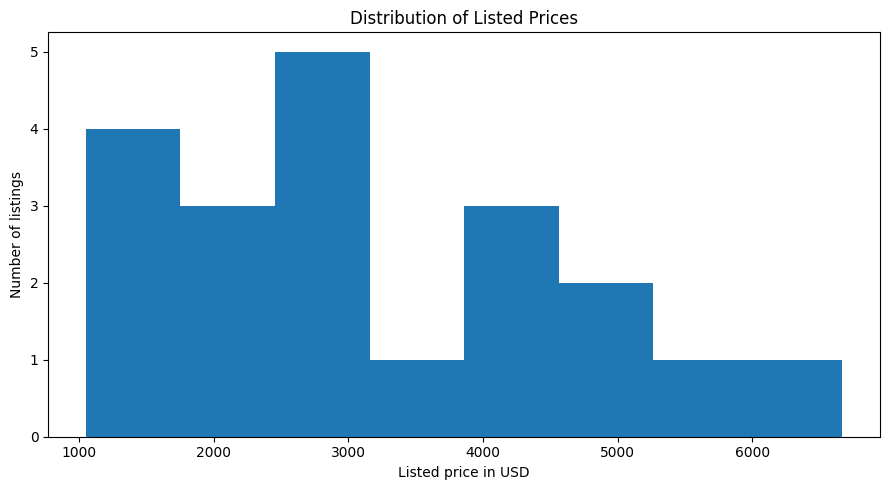

In [9]:
plt.figure(figsize=(9, 5))
plt.hist(data["listed_price_usd"], bins=8)
plt.title("Distribution of Listed Prices")
plt.xlabel("Listed price in USD")
plt.ylabel("Number of listings")
plt.tight_layout()
plt.show()

Listings by review category

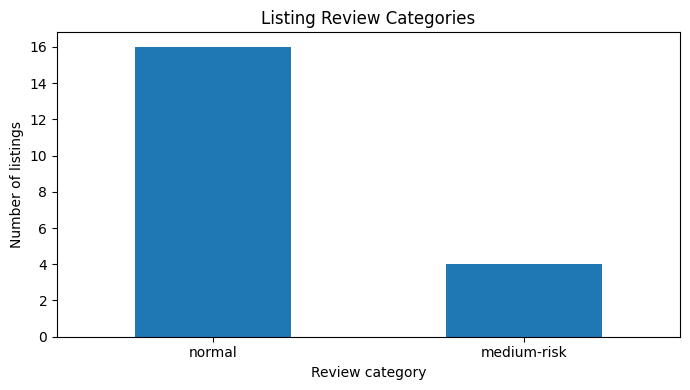

In [10]:
review_counts = data["model_risk_label"].value_counts()

plt.figure(figsize=(7, 4))
review_counts.plot(kind="bar")
plt.title("Listing Review Categories")
plt.xlabel("Review category")
plt.ylabel("Number of listings")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Price per Square Meter by Review Category

This visualization compares price per square meter across the review categories. It helps show whether higher-risk listings have unusual pricing patterns compared with standard listings.

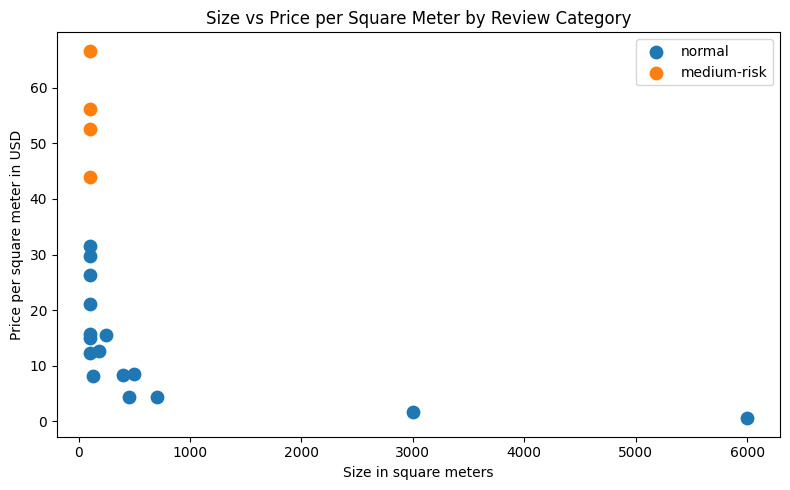

In [11]:
plt.figure(figsize=(8, 5))

categories = data["model_risk_label"].unique()

for category in categories:
    subset = data[data["model_risk_label"] == category]
    plt.scatter(
        subset["size_sqm"],
        subset["price_per_sqm"],
        label=category,
        s=80
    )

plt.title("Size vs Price per Square Meter by Review Category")
plt.xlabel("Size in square meters")
plt.ylabel("Price per square meter in USD")
plt.legend()
plt.tight_layout()
plt.show()

Average price by location

In [12]:
location_summary = (
    data.groupby("location")
    .agg(
        listings=("id", "count"),
        average_price_usd=("listed_price_usd", "mean"),
        average_size_sqm=("size_sqm", "mean"),
    )
    .reset_index()
    .sort_values("average_price_usd", ascending=False)
)

location_summary["average_price_usd"] = location_summary["average_price_usd"].round(0)
location_summary["average_size_sqm"] = location_summary["average_size_sqm"].round(0)

location_summary

,location,listings,average_price_usd,average_size_sqm
0,Akaky Kaliti,4,4452.0,388.0
1,Arada,1,3158.0,100.0
2,Bole,11,3086.0,394.0
3,Kirkos,1,2965.0,100.0
5,Yeka,2,2720.0,3090.0
4,Nifas Silk-Lafto,1,1930.0,450.0


## Model Architecture

This project uses traditional supervised machine learning models rather than a deep neural network.

The model pipeline follows this structure:

Listing data → data cleaning → feature engineering → categorical encoding → numeric feature processing → model training → evaluation.

Two models are trained:

1. Random Forest Regressor  
   This estimates a negotiation reference value for a listing.

2. Random Forest Classifier  
   This classifies listings into review categories such as normal, medium-risk, or suspicious.

Because Random Forest is not a neural network, it does not use layers or activation functions. Instead, it uses multiple decision trees and combines their outputs. For regression, the model averages predictions from many trees. For classification, the model uses voting across trees.

The preprocessing stage uses one-hot encoding for categorical variables such as location and property type. Numeric features such as listed price, size, bedrooms, bathrooms, completeness score, description length, and price per square meter are passed into the model.

## Model Architecture Summary

| Task | Model | Input Features | Output |
|---|---|---|---|
| Price intelligence | Random Forest Regressor | Location, property type, price, size, bedrooms, bathrooms, amenities, completeness score, description length, price per sqm | Negotiation reference value |
| Listing risk screening | Random Forest Classifier | Same listing features | normal, medium-risk, suspicious |

Random Forest was selected because it works well with small structured datasets, handles non-linear relationships, and is easier to explain than a deep learning model at this MVP stage.

Model setup

In [13]:
features = [
    "location",
    "property_type",
    "listed_price_usd",
    "size_sqm",
    "bedrooms",
    "bathrooms",
    "amenities_count",
    "completeness_score",
    "description_length",
    "price_per_sqm",
]

X = data[features]
y_price = data["negotiation_target"]
y_risk = data["model_risk_label"]

categorical_features = ["location", "property_type"]

numeric_features = [
    "listed_price_usd",
    "size_sqm",
    "bedrooms",
    "bathrooms",
    "amenities_count",
    "completeness_score",
    "description_length",
    "price_per_sqm",
]

def build_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
            ("numeric", "passthrough", numeric_features),
        ]
    )

Train regression model

In [14]:
X_train, X_test, y_train_price, y_test_price = train_test_split(
    X,
    y_price,
    test_size=0.25,
    random_state=42,
)

price_model = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor()),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                max_depth=5,
                random_state=42,
            ),
        ),
    ]
)

price_model.fit(X_train, y_train_price)

price_predictions = price_model.predict(X_test)

price_metrics = pd.DataFrame(
    {
        "Metric": ["Mean Absolute Error", "Root Mean Squared Error", "R2 Score"],
        "Value": [
            mean_absolute_error(y_test_price, price_predictions),
            np.sqrt(mean_squared_error(y_test_price, price_predictions)),
            r2_score(y_test_price, price_predictions),
        ],
    }
)

price_metrics

,Metric,Value
0,Mean Absolute Error,390.406000
1,Root Mean Squared Error,481.366746
2,R2 Score,0.790907


Regression prediction comparison

In [15]:
price_results = X_test.copy()
price_results["actual_negotiation_target"] = y_test_price.values
price_results["predicted_negotiation_target"] = price_predictions.round(0)

price_results[
    [
        "location",
        "property_type",
        "listed_price_usd",
        "actual_negotiation_target",
        "predicted_negotiation_target",
    ]
].head(10)

,location,property_type,listed_price_usd,actual_negotiation_target,predicted_negotiation_target
0,Arada,Apartment,3158,3032.0,2801.0
17,Akaky Kaliti,Property,4211,4043.0,4543.0
15,Bole,Property,1053,1011.0,1895.0
1,Kirkos,Apartment,2965,2846.0,2769.0
8,Akaky Kaliti,Commercial,3860,3706.0,3965.0


Train classification model

In [16]:
label_counts = y_risk.value_counts()
can_stratify = label_counts.min() >= 2 and len(label_counts) > 1

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X,
    y_risk,
    test_size=0.25,
    random_state=42,
    stratify=y_risk if can_stratify else None,
)

risk_model = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor()),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                max_depth=5,
                random_state=42,
                class_weight="balanced",
            ),
        ),
    ]
)

risk_model.fit(X_train_cls, y_train_cls)

risk_predictions = risk_model.predict(X_test_cls)

risk_metrics = pd.DataFrame(
    {
        "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
        "Value": [
            accuracy_score(y_test_cls, risk_predictions),
            precision_score(y_test_cls, risk_predictions, average="weighted", zero_division=0),
            recall_score(y_test_cls, risk_predictions, average="weighted", zero_division=0),
            f1_score(y_test_cls, risk_predictions, average="weighted", zero_division=0),
        ],
    }
)

risk_metrics

,Metric,Value
0,Accuracy,1.0
1,Precision,1.0
2,Recall,1.0
3,F1 Score,1.0


Classification report

In [17]:
print(classification_report(y_test_cls, risk_predictions, zero_division=0))

              precision    recall  f1-score   support

 medium-risk       1.00      1.00      1.00         1
      normal       1.00      1.00      1.00         4

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



Confusion matrix

In [18]:
labels = sorted(data["model_risk_label"].unique())

matrix = confusion_matrix(y_test_cls, risk_predictions, labels=labels)

confusion_df = pd.DataFrame(
    matrix,
    index=[f"Actual {label}" for label in labels],
    columns=[f"Predicted {label}" for label in labels],
)

confusion_df

,Predicted medium-risk,Predicted normal
Actual medium-risk,1,0
Actual normal,0,4


Test one listing from the dataset

In [19]:
example = data.iloc[[0]][features]

predicted_price = price_model.predict(example)[0]
predicted_risk = risk_model.predict(example)[0]

print("Listing tested:")
print(data.iloc[0]["title"])
print()
print("Predicted negotiation reference:", round(predicted_price, 0))
print("Predicted review category:", predicted_risk)

Listing tested:
3+ YEARS ON JIJI

Predicted negotiation reference: 2801.0
Predicted review category: normal


Test a higher-risk example

In [20]:
higher_risk_example = pd.DataFrame(
    [
        {
            "location": "Bole",
            "property_type": "Apartment",
            "listed_price_usd": data["listed_price_usd"].quantile(0.90),
            "size_sqm": 80,
            "bedrooms": 2,
            "bathrooms": 2,
            "amenities_count": 1,
            "completeness_score": 0.50,
            "description_length": 25,
            "price_per_sqm": data["listed_price_usd"].quantile(0.90) / 80,
        }
    ]
)

higher_risk_example = higher_risk_example[features]

predicted_price = price_model.predict(higher_risk_example)[0]
predicted_risk = risk_model.predict(higher_risk_example)[0]

print("Higher-risk test example")
print("Predicted negotiation reference:", round(predicted_price, 0))
print("Predicted review category:", predicted_risk)

Higher-risk test example
Predicted negotiation reference: 4576.0
Predicted review category: medium-risk


## Notes on the Results

This notebook uses a small collected dataset, so the model results should be treated as early MVP evidence rather than final production performance.

The regression model estimates a negotiation reference value. It is not a formal property valuation.

The classification model groups listings into review categories based on available listing features. A suspicious label does not prove fraud. It only means the listing should receive additional verification before a buyer proceeds.

The web platform uses the same dataset structure and applies backend review logic to show the user-facing workflow.

## Deployment Option

The deployment option for this ML project is a web-based MVP interface built with Next.js.

The notebook shows the machine learning workflow, while the web platform demonstrates how the model outputs can support a real user experience.

The MVP interface allows a user to:

- Load a collected property listing
- View the listing image and source information
- Run a price and risk review
- View a negotiation reference range
- View a listing risk category
- See map/location context
- Save an evaluation report
- Review flagged listings through an admin page

In the current version, the platform uses backend review logic to demonstrate the workflow. A future version can export the trained model and connect it directly to the backend API.

## Next Steps

The next version of this work should improve the dataset and model quality by:

1. Collecting more listings from multiple property sources.
2. Separating rental listings from sale listings.
3. Adding verified location coordinates.
4. Adding document verification fields where available.
5. Comparing Random Forest with other models such as Linear Regression, XGBoost, Logistic Regression, and SVM.
6. Connecting an exported trained model directly to the web platform backend.

## ML Track Requirement Check

This notebook addresses the ML Track requirements as follows:

1. Data visualization and data engineering  
   The notebook loads the Jiji Ethiopia listing dataset, cleans missing values, creates price per square meter, creates review labels, creates negotiation targets, and visualizes price distribution, review categories, and price per sqm patterns.

2. Model architecture  
   The notebook presents a supervised learning pipeline using preprocessing, one hot encoding, numeric feature processing, a Random Forest Regressor, and a Random Forest Classifier.

3. Initial performance metrics  
   The regression model is evaluated using MAE, RMSE, and R2 Score. The classification model is evaluated using accuracy, precision, recall, F1 Score, classification report, and confusion matrix.

4. Deployment option  
   The deployment option is a Next.js web MVP that demonstrates listing review, price/risk output, map context, saved reports, and admin review.